# Title: Regional tracer intensity in C57BL/6J mice after acute treatment with NS24122 (10 and 30 mg)
# Author: Phillip Muza
# Date: 14/09/2026

The three earlier notebooks measure **where** tracer is, using the pipeline's mask. That mask is built with a per-slice adaptive threshold (hybrid Yen/Otsu, `tracer_segmentation.py`), which adapts to each slice's own contrast: a slice with no tracer still gets a threshold, and a uniform change in how much tracer is present largely cancels out. Those notebooks are therefore comparatively blind to **how much** tracer there is.

This notebook measures amount. `fixed_threshold_intensity.py` re-quantifies every animal with detection and quantification kept independent:

| | how |
|---|---|
| **measured in** | atlas voxels holding tissue (the registered atlas overhangs the sample at its edges; those dark voxels would otherwise subtract a background's worth of intensity from their region, by an amount that tracks registration fit) |
| **detect** | one threshold for the whole brain of an animal × channel: background + 5 × robust SD on the raw 20 µm image |
| **quantify** | raw intensity above that animal's own background, **not** clipped at 0, so noise cancels in the sum rather than accumulating |

Metrics per atlas region × hemisphere, and what each is for:

- **`share`** (primary) - the region's integrated above-background intensity **inside the tracer mask**, as a fraction of that animal's whole-brain in-mask total. Cancels imaging gain and how much tracer got in, so it measures distribution. Compositional: if one region rises, others must fall.
- **`intensity_density`** - the same integral per mm³ of tissue, before the share normalisation.
- **`coverage_pct`** - voxels above the fixed threshold, as % of the region's tissue volume. The pipeline's idea of coverage, on a fixed threshold.
- **mask-free integral** - the same sum over *every* tissue voxel, so it also holds diffuse signal the mask misses. It is **not** used as the primary metric: subtracting one global background per animal leaves about half of all regions negative (tissue autofluorescence varies between regions), and a share built from signed quantities is not interpretable. Step 2 shows the numbers and Step 4 keeps it as a labelled sensitivity.

**Groups:** Vehicle (7), NS24122 10 mg (7), NS24122 30 mg (6); an12, an14, an35 excluded, as in the IVIS analysis. Each dose is compared with Vehicle. The 10 mg animals were run as a later batch.

In [1]:
# import libraries
import os
import json
import itertools
import warnings

import numpy as np
import pandas as pd
import tifffile
from scipy import ndimage, sparse, stats
from scipy.sparse.csgraph import connected_components
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# paths
parent_dir = r'E:\tracer_uptake\wt_mice\new_analysis_0926'
analysis_dir = os.path.join(parent_dir, 'NS24122_intensity')
cache_dir = os.path.join(analysis_dir, 'cache')
atlas_dir = r'C:\Users\skgtpm1\.brainglobe\perens_lsfm_mouse_20um_v1.2'
output_dir = os.path.join(analysis_dir, 'outputs')
os.makedirs(output_dir, exist_ok=True)

VOXEL_MM = 0.02
PSEUDOCOUNT = 1e-5          # added to `share` before log2; justified against the real distribution below
CLUSTER_P = 0.05            # cluster-forming threshold, as a two-sided p for the per-region Welch t
TREATMENT_ORDER = ['Vehicle', 'NS24122_10mg', 'NS24122_30mg']
CONTRASTS = [('NS24122_10mg', 'Vehicle'), ('NS24122_30mg', 'Vehicle')]
TRACERS = ['FITC', 'TxR']

TREATMENT_PALETTE = {'FITC': dict(zip(TREATMENT_ORDER, ['#74C476', '#238B45', '#00441B'])),
                     'TxR': dict(zip(TREATMENT_ORDER, ['#FC9272', '#CB181D', '#67000D']))}
DIRECTION_COLORS = {'up': '#C1666B', 'down': '#4C72B0'}
DIVERGING = LinearSegmentedColormap.from_list('warm_cool', [DIRECTION_COLORS['down'], '#E8E8E8', DIRECTION_COLORS['up']])
INK, MUTED = '#0b0b0b', '#898781'


def short(treatment):
    """'NS24122_10mg' -> '10mg' for compact labels."""
    return treatment.replace('NS24122_', '')


def splits(group_a, group_b):
    """Every re-assignment of the pooled animals into groups of the same sizes (includes the observed one)."""
    pooled = sorted(group_a + group_b, key=lambda a: int(a[2:]))
    for b in itertools.combinations(pooled, len(group_b)):
        yield [x for x in pooled if x not in b], list(b)


def exact_p(values, group_a, group_b):
    """Two-sided exact permutation p for the difference in means of one value per animal."""
    observed = values[group_a].mean() - values[group_b].mean()
    null = np.array([values[a].mean() - values[b].mean() for a, b in splits(group_a, group_b)])
    return float(np.mean(np.abs(null) >= abs(observed) - 1e-12))


regions_df = pd.concat([pd.read_csv(os.path.join(cache_dir, f)) for f in sorted(os.listdir(cache_dir))
                        if f.endswith('_regions.csv')], ignore_index=True)
thresholds = pd.read_csv(os.path.join(analysis_dir, 'threshold_summary.csv'))
animals = sorted(regions_df['animal_number'].unique(), key=lambda a: int(a[2:]))
treatment_of = regions_df.drop_duplicates('animal_number').set_index('animal_number')['treatment'].to_dict()
groups = {t: [a for a in animals if treatment_of[a] == t] for t in TREATMENT_ORDER}

print(f'{regions_df.shape[0]} rows: {regions_df["id"].nunique()} atlas ids x {len(animals)} animals x '
      f'{len(TRACERS)} tracers x 2 hemispheres')
for treatment, members in groups.items():
    print(f'{treatment} (n={len(members)}): {members}')

47870 rows: 629 atlas ids x 20 animals x 2 tracers x 2 hemispheres
Vehicle (n=7): ['an4', 'an7', 'an17', 'an19', 'an21', 'an22', 'an24']
NS24122_10mg (n=7): ['an25', 'an26', 'an29', 'an30', 'an32', 'an33', 'an36']
NS24122_30mg (n=6): ['an2', 'an3', 'an6', 'an10', 'an13', 'an16']


## Step 1 - Segmentation QC

Per animal × channel: the threshold that was used, the background it came from, and what the tissue restriction removed. The last block checks whether these technical quantities differ between groups - if they do, any group difference in the metrics below could be technical rather than biological.

In [2]:
qc = thresholds.assign(order=thresholds['treatment'].map(TREATMENT_ORDER.index)).sort_values(['tracer', 'order', 'animal_number'])
with pd.option_context('display.float_format', '{:.3f}'.format, 'display.width', 220):
    print(qc[['animal_number', 'treatment', 'tracer', 'bg_raw', 'sd_raw', 'threshold', 'tissue_fraction_of_atlas',
              'coverage_pct_brain', 'integrated_all_brain', 'integrated_in_mask_brain']].to_string(index=False))

print('\nGroup means of the technical quantities, with Welch p vs Vehicle:')
rows = []
for tracer in TRACERS:
    t = thresholds[thresholds['tracer'] == tracer]
    for column in ['bg_raw', 'sd_raw', 'threshold', 'tissue_fraction_of_atlas', 'coverage_pct_brain', 'integrated_all_brain']:
        row = {'tracer': tracer, 'quantity': column}
        for g in TREATMENT_ORDER:
            row[short(g)] = t.loc[t['treatment'] == g, column].mean()
        for treatment, reference in CONTRASTS:
            row[f'p_{short(treatment)}'] = stats.ttest_ind(t.loc[t['treatment'] == treatment, column],
                                                           t.loc[t['treatment'] == reference, column], equal_var=False)[1]
        rows.append(row)
with pd.option_context('display.float_format', '{:.4g}'.format, 'display.width', 200):
    print(pd.DataFrame(rows).to_string(index=False))

animal_number    treatment tracer   bg_raw  sd_raw  threshold  tissue_fraction_of_atlas  coverage_pct_brain  integrated_all_brain  integrated_in_mask_brain
         an17      Vehicle   FITC  868.000 188.290   1809.451                     0.968               0.079        1642953728.000              73809072.000
         an19      Vehicle   FITC  913.000 244.629   2136.145                     0.980               0.217        2453214464.000             304449760.000
         an21      Vehicle   FITC  961.000 194.221   1932.103                     0.956               0.620        2412897792.000             877060800.000
         an22      Vehicle   FITC  957.000 247.594   2194.971                     0.964               0.851        2534844416.000            1337337088.000
         an24      Vehicle   FITC  965.000 265.385   2291.927                     0.975               1.267        5088893952.000            2748094976.000
          an4      Vehicle   FITC  872.000 188.290   1813.451   

## Step 2 - Region set and metrics

The region set is the atlas regions with tissue in **both** hemispheres of **all** animals, so one set serves every comparison. `share` is the region's integrated above-background intensity divided by that animal's whole-brain total, computed per tracer.

In [3]:
present = (regions_df.pivot_table(index='id', columns=['animal_number', 'hemisphere', 'tracer'],
                                  values='volume_mm3', aggfunc='first') > 0)
region_ids = sorted(present.index[present.all(axis=1)])
print(f'atlas ids with tissue in both hemispheres of all {len(animals)} animals: {len(region_ids)}')

df = regions_df[regions_df['id'].isin(region_ids)].copy()
for column in ('integrated_in_mask', 'integrated_all'):
    total = df.groupby(['animal_number', 'tracer'])[column].sum().rename('total')
    df = df.join(total, on=['animal_number', 'tracer'])
    df[f'share_{column}'] = df[column] / df['total']
    df = df.drop(columns='total')
df['share'] = df['share_integrated_in_mask']          # primary, see below
df['intensity_density'] = df['integrated_in_mask'] / df['volume_mm3']

# Which of the two integrals to normalise: the mask-free one turns out not to be usable here.
print('\nnegative values, which a "share of the animal\'s signal" should not have:')
for column in ('integrated_in_mask', 'integrated_all'):
    print(f'  share_{column:18}: {(df[f"share_{column}"] < 0).mean():.1%} of region x animal values')
print("""
The mask-free integral subtracts one global background per animal, but tissue autofluorescence varies
between regions, so about half of all regions sit below that global level and get a negative total.
A share computed from signed quantities is not interpretable (the isocortex comes out at -0.53 of the
animal's "total"), and its denominator is a sum of positive and negative parts, so it is unstable.
The mask-based integral only sums voxels above the animal's detection threshold: never negative,
specific to tracer, and the measure closest to masking the raw image with the tracer mask.
=> primary metric = integrated_in_mask / the animal's whole-brain in-mask total.
The mask-free version is kept as a labelled sensitivity in Step 4 and should not be read on its own.""")
print(df.groupby('tracer')['share'].describe().round(5).to_string())

# one matrix per tracer: regions x animals, both hemispheres pooled (the question here is amount, not laterality)
pooled = (df.groupby(['tracer', 'animal_number', 'id'])[['integrated_in_mask', 'integrated_all', 'volume_mm3']]
            .sum().reset_index())
for column in ('integrated_in_mask', 'integrated_all'):
    total = pooled.groupby(['tracer', 'animal_number'])[column].sum().rename('total')
    pooled = pooled.join(total, on=['tracer', 'animal_number'])
    pooled[f'share_{column}'] = pooled[column] / pooled['total']
    pooled = pooled.drop(columns='total')
share = {tracer: pooled[pooled['tracer'] == tracer].pivot(index='id', columns='animal_number', values='share_integrated_in_mask')
                       .loc[region_ids, animals] for tracer in TRACERS}
share_mask_free = {tracer: pooled[pooled['tracer'] == tracer].pivot(index='id', columns='animal_number', values='share_integrated_all')
                                 .loc[region_ids, animals] for tracer in TRACERS}
for tracer in TRACERS:
    v = share[tracer].to_numpy().ravel()
    print(f'{tracer}: share per region ranges {v.min():.2e} to {v.max():.2e}, median {np.median(v):.2e}; '
          f'pseudocount {PSEUDOCOUNT:.0e} sits at the {100 * np.mean(v < PSEUDOCOUNT):.0f}th percentile')

log_share = {tracer: np.log2(share[tracer] + PSEUDOCOUNT) for tracer in TRACERS}

atlas ids with tissue in both hemispheres of all 20 animals: 566

negative values, which a "share of the animal's signal" should not have:
  share_integrated_in_mask: 0.0% of region x animal values
  share_integrated_all    : 47.9% of region x animal values

The mask-free integral subtracts one global background per animal, but tissue autofluorescence varies
between regions, so about half of all regions sit below that global level and get a negative total.
A share computed from signed quantities is not interpretable (the isocortex comes out at -0.53 of the
animal's "total"), and its denominator is a sum of positive and negative parts, so it is unstable.
The mask-based integral only sums voxels above the animal's detection threshold: never negative,
specific to tracer, and the measure closest to masking the raw image with the tracer mask.
=> primary metric = integrated_in_mask / the animal's whole-brain in-mask total.
The mask-free version is kept as a labelled sensitivity in Step 4 and

## Step 3 - The 15 collated divisions

The same divisions as the other notebooks, on the intensity metrics: each dose vs Vehicle, Welch's t-test, Benjamini-Hochberg FDR within tracer across the 15 divisions × 2 comparisons.

In [4]:
with open(os.path.join(atlas_dir, 'structures.json')) as f:
    structures = json.load(f)
acronym_of = {s['id']: s['acronym'] for s in structures}
name_of = {s['id']: s['name'] for s in structures}
path_of = {s['id']: s['structure_id_path'] for s in structures}

region_dict = {
    'Isocortex': 315, 'Olfactory Areas': 698, 'Hippocampal Formation': 1089,
    'Amygdala': (295, 319, 131, 780), 'Cortical Subplate (other)': (583, 942),
    'Striatum': 477, 'Pallidum': 803, 'Thalamus': 549, 'Hypothalamus': 1097,
    'Midbrain': 313, 'Pons': 771, 'Medulla': 354, 'Cerebellum': 512,
    'Fiber Tracts': 1009, 'Ventricular Systems': 73,
}


def division_of(region_id):
    """The collated division a region belongs to, via its structure_id_path; None if it is in none of them."""
    path = path_of.get(region_id, [])
    for division, roots in region_dict.items():
        for root in (roots if isinstance(roots, tuple) else (roots,)):
            if root in path:
                return division
    return None


df['division'] = df['id'].map(division_of)
divisions = list(region_dict)
collated = (df.dropna(subset=['division'])
              .groupby(['animal_number', 'treatment', 'tracer', 'division'])
              .agg(integrated_in_mask=('integrated_in_mask', 'sum'), volume_mm3=('volume_mm3', 'sum'),
                   n_voxels_above=('n_voxels_above', 'sum'))
              .reset_index())
animal_total = df.groupby(['animal_number', 'tracer'])['integrated_in_mask'].sum().rename('animal_total')
collated = collated.join(animal_total, on=['animal_number', 'tracer'])
collated['share'] = collated['integrated_in_mask'] / collated['animal_total']
collated['intensity_density'] = collated['integrated_in_mask'] / collated['volume_mm3']
collated['coverage_pct'] = 100 * collated['n_voxels_above'] * (VOXEL_MM ** 3) / collated['volume_mm3']

METRIC = 'share'
METRIC_LABEL = {'share': 'share of the animal\'s total tracer signal',
                'intensity_density': 'integrated intensity per mm³',
                'coverage_pct': '% of tissue volume above threshold'}


def compare(data, value_col, group_col='division', order=None):
    """Each dose vs Vehicle per tracer x group_col: means, log2 fold change, Welch p, FDR within tracer."""
    records = []
    for (tracer, key), g in data.groupby(['tracer', group_col]):
        for treatment, reference in CONTRASTS:
            a = g.loc[g['treatment'] == treatment, value_col].dropna()
            b = g.loc[g['treatment'] == reference, value_col].dropna()
            if len(a) < 2 or len(b) < 2:
                continue
            fold = a.mean() / b.mean() if b.mean() else np.nan
            records.append({'tracer': tracer, group_col: key, 'treatment': treatment,
                            'mean_reference': b.mean(), 'sem_reference': b.sem(),
                            'mean_treatment': a.mean(), 'sem_treatment': a.sem(),
                            'fold_change': fold, 'log2fc': np.log2(fold) if fold and fold > 0 else np.nan,
                            'p_value': stats.ttest_ind(a, b, equal_var=False)[1]})
    result = pd.DataFrame(records)
    result['p_adj'] = np.nan
    for tracer in result['tracer'].unique():
        mask = result['tracer'] == tracer
        result.loc[mask, 'p_adj'] = multipletests(result.loc[mask, 'p_value'], method='fdr_bh')[1]
    if order is not None:
        result[group_col] = pd.Categorical(result[group_col], order, ordered=True)
    return result.sort_values(['tracer', 'treatment', 'p_value']).reset_index(drop=True)


division_results = compare(collated, METRIC, order=divisions)
print(f'Outcome: {METRIC_LABEL[METRIC]}')
with pd.option_context('display.max_rows', None, 'display.float_format', '{:.4f}'.format, 'display.width', 200):
    for (tracer, treatment), table in division_results.groupby(['tracer', 'treatment'], observed=True):
        print(f'\n{tracer}: {treatment} vs Vehicle')
        print(table.drop(columns=['tracer', 'treatment']).to_string(index=False))

Outcome: share of the animal's total tracer signal

FITC: NS24122_10mg vs Vehicle


                 division  mean_reference  sem_reference  mean_treatment  sem_treatment  fold_change  log2fc  p_value  p_adj
                 Midbrain          0.0474         0.0104          0.1273         0.0269       2.6838  1.4243   0.0251 0.2163
                 Pallidum          0.0131         0.0031          0.0050         0.0015       0.3773 -1.4062   0.0424 0.2163
                     Pons          0.0262         0.0045          0.1381         0.0444       5.2788  2.4002   0.0451 0.2163
          Olfactory Areas          0.2515         0.0345          0.1322         0.0408       0.5258 -0.9275   0.0458 0.2163
             Hypothalamus          0.0383         0.0106          0.0115         0.0058       0.3007 -1.7336   0.0541 0.2163
                 Striatum          0.0836         0.0178          0.0520         0.0117       0.6217 -0.6857   0.1665 0.4459
Cortical Subplate (other)          0.0037         0.0014          0.0017         0.0005       0.4557 -1.1338   0.2250 0.4846


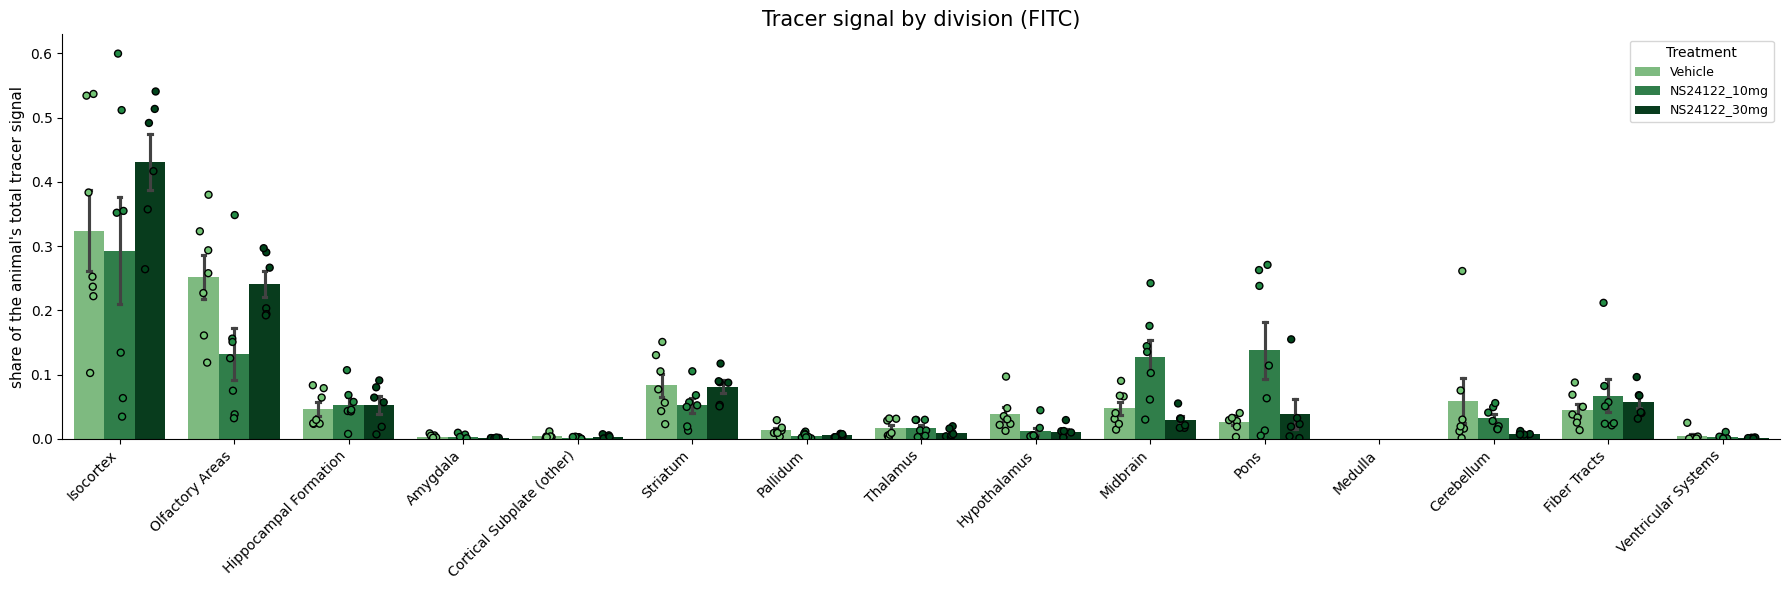

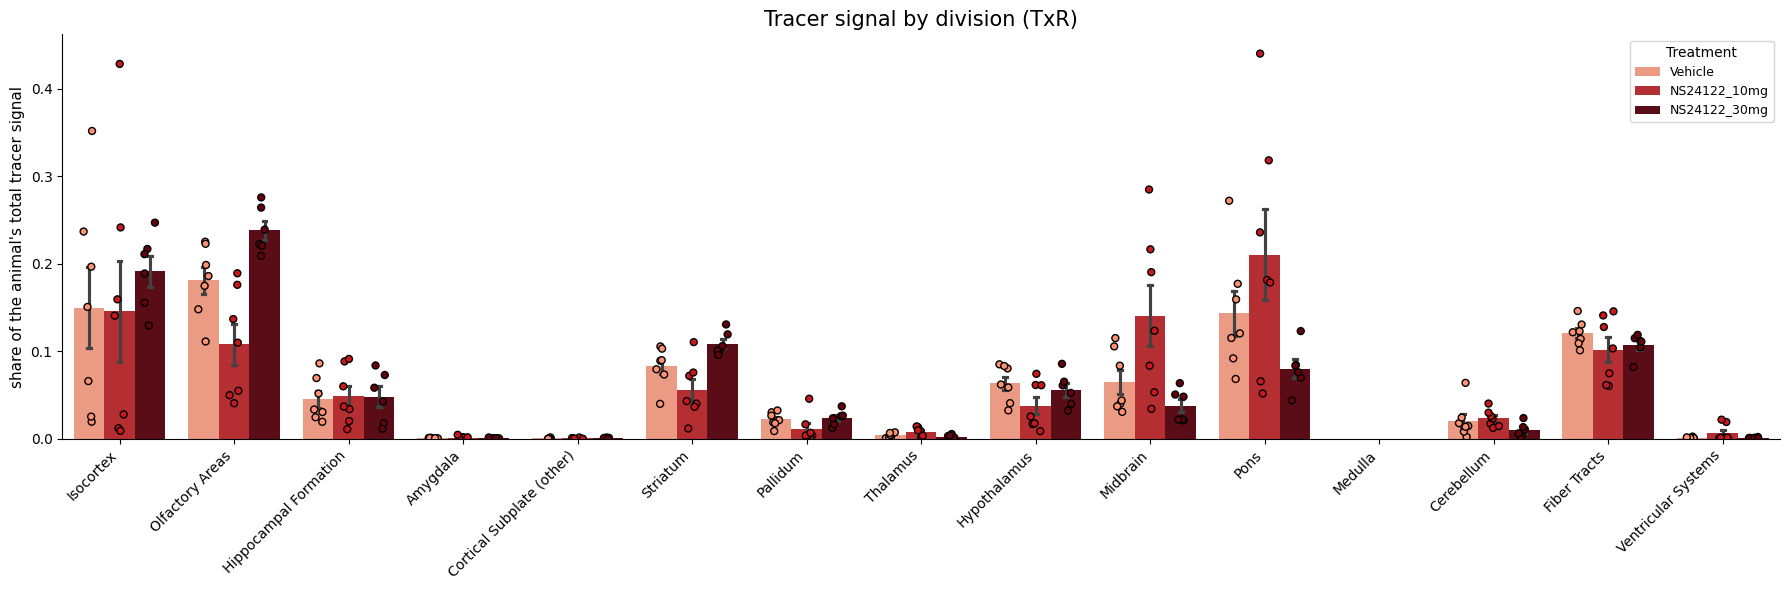

In [5]:
# bar plots of the collated divisions, one panel per tracer
for tracer in TRACERS:
    data = collated[collated['tracer'] == tracer]
    fig, ax = plt.subplots(figsize=(18, 6))
    sns.barplot(data=data, x='division', y=METRIC, order=divisions, hue='treatment', hue_order=TREATMENT_ORDER,
                palette=TREATMENT_PALETTE[tracer], errorbar='se', capsize=0.1, ax=ax)
    sns.stripplot(data=data, x='division', y=METRIC, order=divisions, hue='treatment', hue_order=TREATMENT_ORDER,
                  palette=TREATMENT_PALETTE[tracer], dodge=True, edgecolor='black', linewidth=1, size=5,
                  jitter=0.15, legend=False, ax=ax)
    for x, division in enumerate(divisions):
        for k, (treatment, _) in enumerate(CONTRASTS):
            row = division_results[(division_results['tracer'] == tracer) & (division_results['division'] == division)
                                   & (division_results['treatment'] == treatment)]
            if len(row) and row['p_adj'].iloc[0] < 0.05:
                ax.text(x, ax.get_ylim()[1] * (0.95 - 0.05 * k), f'* {short(treatment)}', ha='center', fontsize=9)
    ax.set_title(f'Tracer signal by division ({tracer})', fontsize=15)
    ax.set_xlabel('')
    ax.set_ylabel(METRIC_LABEL[METRIC], fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(title='Treatment', fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.show()

## Step 4 - Confirmatory test: the ventral midbrain / pons region set

`NS24122_spatial_autocorrelation_analysis.ipynb` found, on the pipeline's coverage metric, that NS24122 animals had less tracer in a contiguous band of the ventral midbrain, pons and hypothalamus (22 regions, TxR, left hemisphere, p_FWER = 0.001, with the right hemisphere and FITC going the same way). That region set was fixed there, and intensity is a largely different measurement of the same images, so testing exactly those regions here is confirmatory rather than exploratory - one test per tracer per dose, no searching.

22 of the 22 cluster regions are in the region set: SNr, PG, ml, LHA, MT, POR, ll, cpd, mp, mcp, NDB, IPC, TRN, MMl, MMp, NLL, MPO, IPI, BST, IPL, PN, int


Primary metric (share of the animal's in-mask signal):
tracer      comparison  mean_Vehicle  mean_dose  ratio  p_welch  p_exact  p_holm
  FITC 10mg vs Vehicle        0.0455     0.0568 1.2483   0.5710   0.5571  0.7781
  FITC 30mg vs Vehicle        0.0455     0.0292 0.6424   0.3890   0.3992  0.7781
   TxR 10mg vs Vehicle        0.1941     0.1451 0.7478   0.2376   0.2372  0.7128
   TxR 30mg vs Vehicle        0.1941     0.0975 0.5024   0.0222   0.0233  0.0888

Same region set under each alternative:
tracer                      variant      comparison  mean_Vehicle  mean_dose  ratio  p_welch
  FITC primary (in-mask, with fill) 10mg vs Vehicle        0.0455     0.0568 1.2483   0.5710
  FITC primary (in-mask, with fill) 30mg vs Vehicle        0.0455     0.0292 0.6424   0.3890
  FITC           mask-free integral 10mg vs Vehicle        0.3014     0.1842 0.6111   0.0203
  FITC           mask-free integral 30mg vs Vehicle        0.3014     0.1921 0.6374   0.1155
  FITC             in-mask, no fil

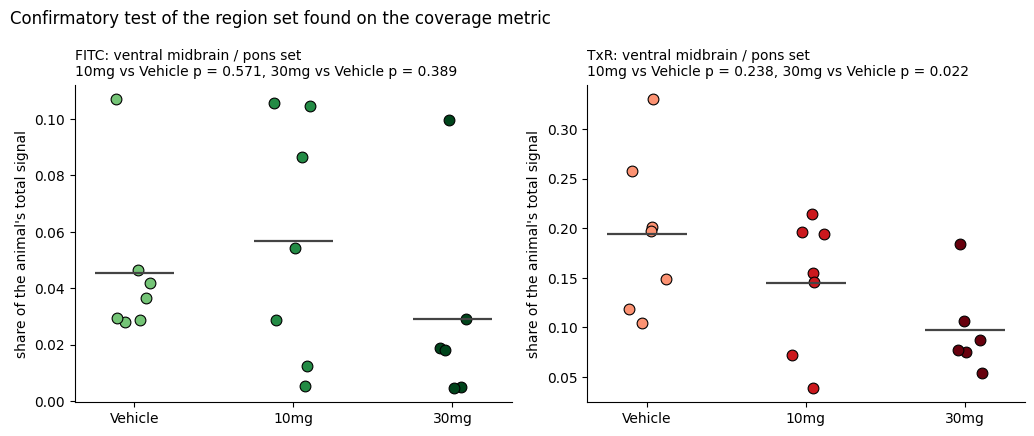

In [6]:
VENTRAL_SET = "SNr PG ml LHA MT POR ll cpd mp mcp NDB IPC TRN MMl MMp NLL MPO IPI BST IPL PN int".split()
id_of = {a: i for i, a in acronym_of.items()}
ventral_ids = [id_of[a] for a in VENTRAL_SET if id_of[a] in region_ids]
print(f'{len(ventral_ids)} of the {len(VENTRAL_SET)} cluster regions are in the region set: '
      f'{", ".join(acronym_of[i] for i in ventral_ids)}')

rows = []
for tracer in TRACERS:
    value = share[tracer].loc[ventral_ids].sum(axis=0)          # the set's share of that animal's total
    for treatment, reference in CONTRASTS:
        a, b = value[groups[treatment]], value[groups[reference]]
        t_stat, p = stats.ttest_ind(a, b, equal_var=False)
        rows.append({'tracer': tracer, 'comparison': f'{short(treatment)} vs Vehicle',
                     'mean_Vehicle': b.mean(), 'mean_dose': a.mean(), 'ratio': a.mean() / b.mean(),
                     'p_welch': p, 'p_exact': exact_p(value, groups[treatment], groups[reference])})
ventral_df = pd.DataFrame(rows)
ventral_df['p_holm'] = multipletests(ventral_df['p_welch'], method='holm')[1]
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 200):
    print('Primary metric (share of the animal\'s in-mask signal):')
    print(ventral_df.to_string(index=False))

# the same test under the two alternatives, so it is visible which conclusions depend on those choices:
# the mask-free integral (not interpretable on its own, see Step 2) and dropping the 200 um fill of
# signal that registration places just outside the atlas - the fill is where the group difference in
# registration fit would enter
sensitivity_rows = []
nofill_dir = os.path.join(analysis_dir, 'cache_nofill')
nofill = pd.concat([pd.read_csv(os.path.join(nofill_dir, f)) for f in sorted(os.listdir(nofill_dir))
                    if f.endswith('_regions.csv')], ignore_index=True)
nofill = nofill[nofill['id'].isin(region_ids)]
nofill_total = nofill.groupby(['animal_number', 'tracer'])['integrated_in_mask'].sum()
for tracer in TRACERS:
    variants = {
        'primary (in-mask, with fill)': share[tracer].loc[ventral_ids].sum(axis=0),
        'mask-free integral': share_mask_free[tracer].loc[ventral_ids].sum(axis=0),
        'in-mask, no fill': (nofill[(nofill['tracer'] == tracer) & nofill['id'].isin(ventral_ids)]
                             .groupby('animal_number')['integrated_in_mask'].sum()
                             / nofill_total.xs(tracer, level='tracer')),
        'coverage (fixed threshold)': (df[(df['tracer'] == tracer) & df['id'].isin(ventral_ids)]
                                       .groupby('animal_number')[['n_voxels_above', 'volume_mm3']]
                                       .sum().pipe(lambda g: 100 * g['n_voxels_above'] * VOXEL_MM ** 3 / g['volume_mm3'])),
    }
    for name, value in variants.items():
        for treatment, reference in CONTRASTS:
            a, b = value[groups[treatment]], value[groups[reference]]
            sensitivity_rows.append({'tracer': tracer, 'variant': name, 'comparison': f'{short(treatment)} vs Vehicle',
                                     'mean_Vehicle': b.mean(), 'mean_dose': a.mean(), 'ratio': a.mean() / b.mean(),
                                     'p_welch': stats.ttest_ind(a, b, equal_var=False)[1]})
ventral_sensitivity = pd.DataFrame(sensitivity_rows)
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.width', 200):
    print('\nSame region set under each alternative:')
    print(ventral_sensitivity.to_string(index=False))

fig, axes = plt.subplots(1, len(TRACERS), figsize=(5.2 * len(TRACERS), 4.4))
rng = np.random.default_rng(0)
for ax, tracer in zip(axes, TRACERS):
    value = share[tracer].loc[ventral_ids].sum(axis=0)
    for x, treatment in enumerate(TREATMENT_ORDER):
        v = value[groups[treatment]]
        ax.scatter(x + rng.uniform(-0.12, 0.12, len(v)), v, s=60, color=TREATMENT_PALETTE[tracer][treatment],
                   edgecolor='black', linewidth=0.8, zorder=3)
        ax.hlines(v.mean(), x - 0.25, x + 0.25, color='#444444', lw=1.6, zorder=4)
    ax.set_xticks(range(len(TREATMENT_ORDER)))
    ax.set_xticklabels([short(t) for t in TREATMENT_ORDER])
    ax.set_ylabel('share of the animal\'s total signal', fontsize=10)
    res = ventral_df[ventral_df['tracer'] == tracer]
    ax.set_title(f'{tracer}: ventral midbrain / pons set\n' +
                 ', '.join(f"{r['comparison']} p = {r['p_welch']:.3f}" for _, r in res.iterrows()),
                 fontsize=10, loc='left')
    sns.despine(ax=ax)
fig.suptitle('Confirmatory test of the region set found on the coverage metric', x=0.01, ha='left', fontsize=12)
plt.tight_layout()
plt.show()

## Step 5 - Whole-brain search: where does the amount of tracer differ?

The cluster-mass permutation test of the laterality notebook, applied here to the **amount** of tracer with both hemispheres pooled - the whole-brain version that the earlier notebooks did not run. Per region, Welch's t of log2(share) between a dose and Vehicle; supra-threshold regions of the same sign that touch each other form clusters; a cluster's mass is compared against the largest cluster mass over every animal split of that comparison, which controls the family-wise error across the whole brain.

In [7]:
annotation = tifffile.imread(os.path.join(atlas_dir, 'annotation.tiff'))
midline = annotation.shape[2] // 2
annotation_R = annotation.copy()
annotation_R[:, :, :midline] = 0


def face_adjacency(label_volume):
    """Every pair of labels sharing a voxel face anywhere in the volume."""
    pairs = []
    for axis in range(label_volume.ndim):
        a = np.moveaxis(label_volume, axis, 0)
        lo, hi = a[:-1], a[1:]
        touching = (lo != hi) & (lo != 0) & (hi != 0)
        pairs.append(np.unique(np.sort(np.stack([lo[touching], hi[touching]], axis=1), axis=1), axis=0))
    return np.unique(np.concatenate(pairs), axis=0)


region_index = {rid: i for i, rid in enumerate(region_ids)}
neighbors = {i: [] for i in range(len(region_ids))}
for a, b in face_adjacency(annotation_R):
    a, b = int(a), int(b)
    if a in region_index and b in region_index:
        neighbors[region_index[a]].append(region_index[b])
        neighbors[region_index[b]].append(region_index[a])
rows = [i for i, nb in neighbors.items() for _ in nb]
cols = [j for nb in neighbors.values() for j in nb]
adj = sparse.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(region_ids),) * 2)
adj = ((adj + adj.T) > 0).astype(np.int8).tocsr()
n_components, _ = connected_components(adj, directed=False)
print(f'contiguity graph: {adj.nnz // 2} edges over {len(region_ids)} regions, {n_components} connected component(s)')


def welch_t(x, cols_a, cols_b):
    """Welch t per region (row) between two sets of columns; 0 where neither group varies."""
    a, b = x[:, cols_a], x[:, cols_b]
    diff = a.mean(axis=1) - b.mean(axis=1)
    se = np.sqrt(a.var(axis=1, ddof=1) / a.shape[1] + b.var(axis=1, ddof=1) / b.shape[1])
    return np.divide(diff, se, out=np.zeros_like(diff), where=se > 1e-12)


def find_clusters(t, adjacency, threshold):
    """Same-sign connected components among supra-threshold regions -> (sign, members, mass)."""
    clusters = []
    for sign in (1, -1):
        idx = np.flatnonzero(sign * t >= threshold)
        if idx.size == 0:
            continue
        n_comp, labels = connected_components(adjacency[idx][:, idx], directed=False)
        for c in range(n_comp):
            members = idx[labels == c]
            clusters.append((sign, members, float(np.abs(t[members]).sum())))
    return clusters


def cluster_test(x, group_a, group_b, adjacency, threshold):
    """Cluster-mass test with family-wise error from the maximum cluster mass over every animal split."""
    values = x.to_numpy()
    col = {a: i for i, a in enumerate(x.columns)}
    take = lambda names: [col[n] for n in names]
    observed = welch_t(values, take(group_a), take(group_b))
    max_mass = np.array([max((m for _, _, m in find_clusters(welch_t(values, take(a), take(b)), adjacency, threshold)), default=0.0)
                         for a, b in splits(group_a, group_b)])
    clusters = [{'sign': s, 'members': m, 'n_regions': len(m), 'mass': mass,
                 'p_fwer': float(np.mean(max_mass >= mass - 1e-9))}
                for s, m, mass in find_clusters(observed, adjacency, threshold)]
    return observed, sorted(clusters, key=lambda c: -c['mass']), max_mass


def describe(members, t, max_names=12):
    """Member acronyms, strongest first."""
    order = members[np.argsort(-np.abs(t[members]))]
    names = [acronym_of[region_ids[i]] for i in order[:max_names]]
    return ', '.join(names) + (f' (+{len(order) - max_names} more)' if len(order) > max_names else '')


cluster_results, cluster_rows = {}, []
for tracer in TRACERS:
    for treatment, reference in CONTRASTS:
        a, b = groups[treatment], groups[reference]
        threshold = float(stats.t.ppf(1 - CLUSTER_P / 2, len(a) + len(b) - 2))
        t_map, clusters, max_mass = cluster_test(log_share[tracer], a, b, adj, threshold)
        cluster_results[(tracer, treatment)] = {'t': t_map, 'clusters': clusters, 'max_mass': max_mass}
        for k, c in enumerate(clusters):
            cluster_rows.append({'tracer': tracer, 'comparison': f'{short(treatment)} vs Vehicle', 'cluster': k + 1,
                                 'direction': f'higher in {short(treatment)}' if c['sign'] > 0 else f'lower in {short(treatment)}',
                                 'n_regions': c['n_regions'], 'mass': c['mass'], 'p_fwer': c['p_fwer'],
                                 'regions': describe(c['members'], t_map)})
        top = clusters[0] if clusters else None
        print(f"{tracer}, {short(treatment)} vs Vehicle: {len(clusters)} clusters, largest "
              f"{top['n_regions'] if top else 0} regions, mass {top['mass'] if top else 0:.1f}, "
              f"p_FWER = {top['p_fwer'] if top else 1:.3f} ({len(max_mass)} splits)")

cluster_df = pd.DataFrame(cluster_rows)
print('\nClusters with at least 3 regions or p_FWER < 0.2:')
with pd.option_context('display.float_format', '{:.3f}'.format, 'display.width', 250, 'display.max_colwidth', 120):
    print(cluster_df[(cluster_df['n_regions'] >= 3) | (cluster_df['p_fwer'] < 0.2)].to_string(index=False)
          if len(cluster_df) else 'none')

contiguity graph: 4559 edges over 566 regions, 1 connected component(s)


FITC, 10mg vs Vehicle: 13 clusters, largest 7 regions, mass 19.2, p_FWER = 0.386 (3432 splits)


FITC, 30mg vs Vehicle: 12 clusters, largest 25 regions, mass 74.6, p_FWER = 0.031 (1716 splits)


TxR, 10mg vs Vehicle: 9 clusters, largest 29 regions, mass 84.6, p_FWER = 0.045 (3432 splits)


TxR, 30mg vs Vehicle: 10 clusters, largest 29 regions, mass 87.7, p_FWER = 0.024 (1716 splits)

Clusters with at least 3 regions or p_FWER < 0.2:
tracer      comparison  cluster      direction  n_regions   mass  p_fwer                                                                  regions
  FITC 10mg vs Vehicle        1  lower in 10mg          7 19.245   0.386                       AIv1, AIv2/3, ORBvl1, AIp1, AIp2/3, PERI1, ORBl2/3
  FITC 10mg vs Vehicle        2 higher in 10mg          4 12.199   0.565                                                     SCsg, NB, SCig, SCzo
  FITC 10mg vs Vehicle        3 higher in 10mg          3  8.081   0.732                                                              scp, cst, P
  FITC 10mg vs Vehicle        5  lower in 10mg          3  7.661   0.766                                                            MMp, SUM, MMl
  FITC 30mg vs Vehicle        1  lower in 30mg         25 74.646   0.031       LSr, ml, MPO, SMT, SPFm, VLPO, MT, PF, RH, LS

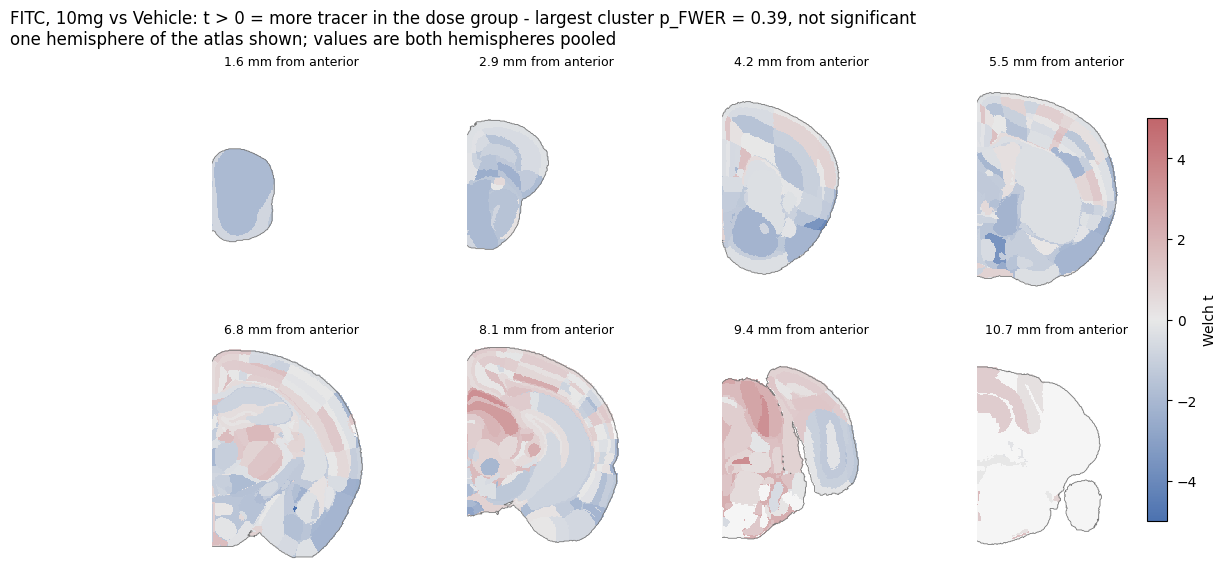

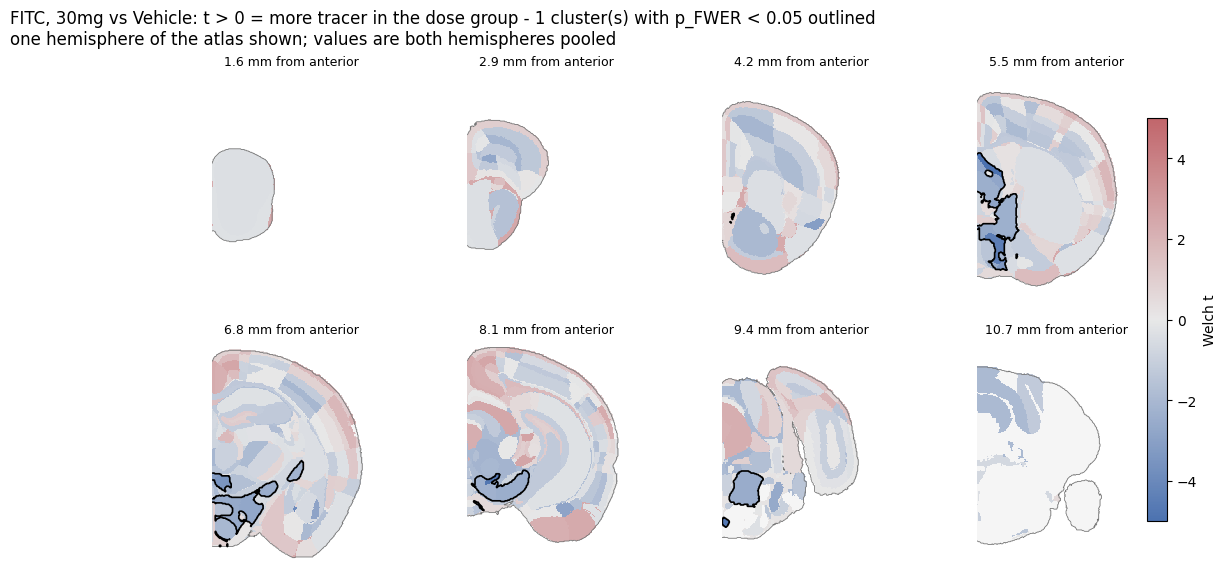

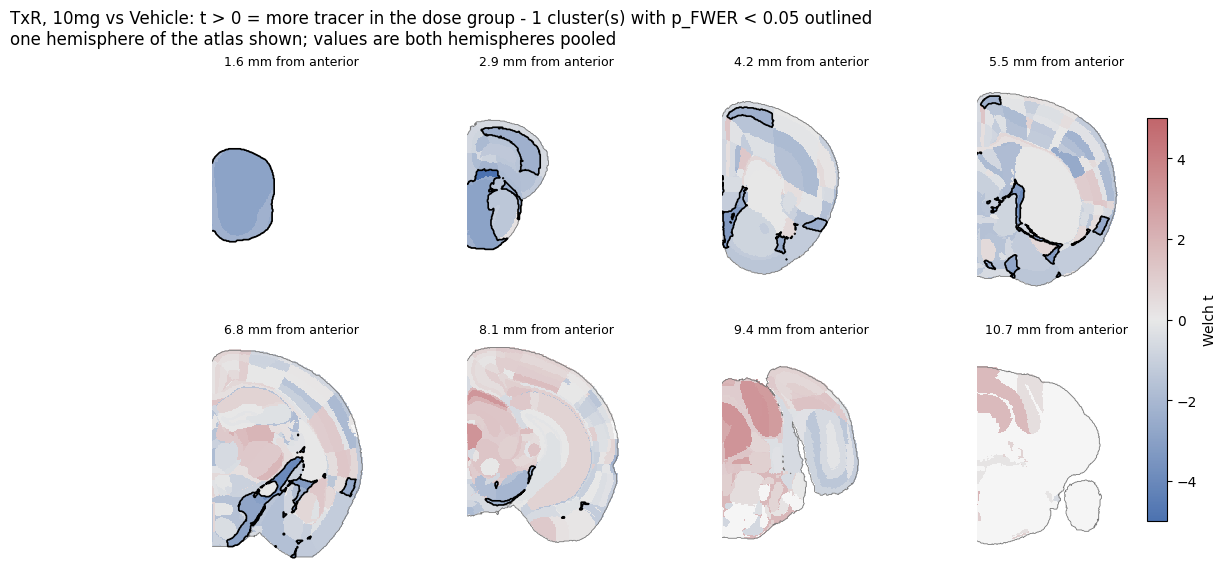

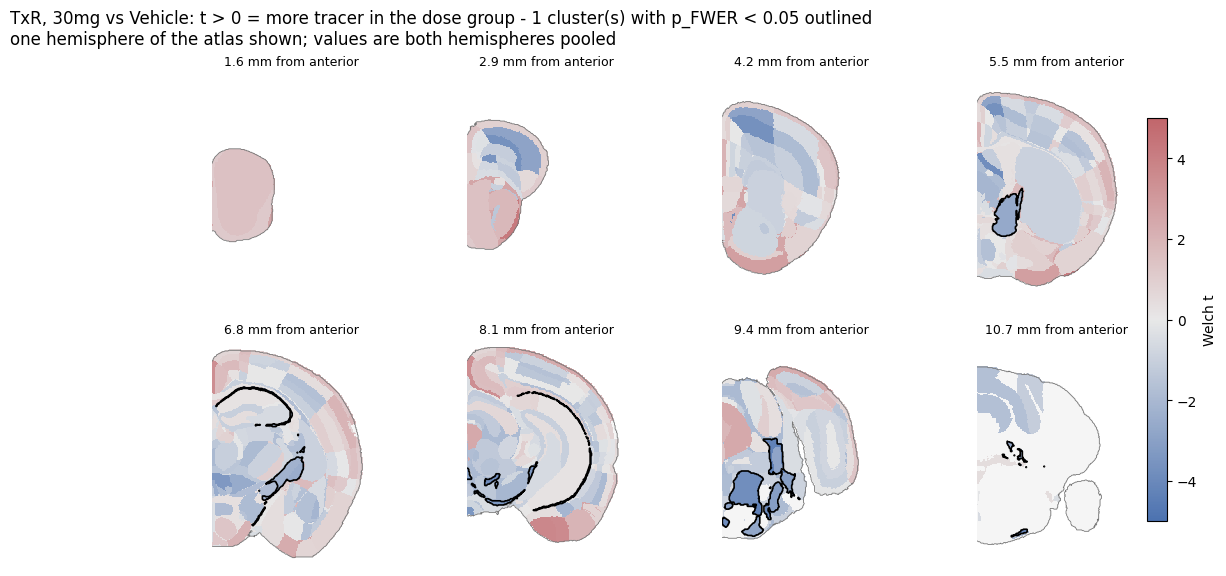

In [8]:
# maps of the per-region effect, with any significant cluster outlined
def plot_map(values, title, outline=(), vmax=5.0, n_slices=8):
    value_of = pd.Series(np.asarray(values, dtype=float), index=region_ids)
    outline = set(outline)
    extent = np.flatnonzero((annotation_R > 0).any(axis=(1, 2)))
    planes = np.linspace(extent[0] + 0.12 * len(extent), extent[-1] - 0.12 * len(extent), n_slices).astype(int)
    fig, axes = plt.subplots(2, n_slices // 2, figsize=(3.3 * n_slices // 2, 6.4))
    for ax, ap in zip(axes.flat, planes):
        labels = annotation_R[ap, :, midline:]
        uniq, inverse = np.unique(labels, return_inverse=True)
        painted = value_of.reindex(uniq).to_numpy()[inverse].reshape(labels.shape)
        ax.imshow(np.where(labels > 0, 1.0, np.nan), cmap='Greys', vmin=0, vmax=12, interpolation='nearest')
        im = ax.imshow(painted, cmap=DIVERGING, vmin=-vmax, vmax=vmax, interpolation='nearest')
        ax.contour(labels > 0, levels=[0.5], colors='#777777', linewidths=0.6)
        if outline:
            ax.contour(np.isin(labels, list(outline)), levels=[0.5], colors='black', linewidths=1.2)
        ax.set_title(f'{ap * VOXEL_MM:.1f} mm from anterior', fontsize=9)
        ax.set_axis_off()
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01, label='Welch t')
    fig.suptitle(title, x=0.01, ha='left', fontsize=12)
    plt.show()


for tracer in TRACERS:
    for treatment, _ in CONTRASTS:
        res = cluster_results[(tracer, treatment)]
        significant = [c for c in res['clusters'] if c['p_fwer'] < 0.05]
        members = [region_ids[i] for c in significant for i in c['members']]
        note = (f'{len(significant)} cluster(s) with p_FWER < 0.05 outlined' if significant
                else f"largest cluster p_FWER = {res['clusters'][0]['p_fwer']:.2f}, not significant" if res['clusters']
                else 'no supra-threshold regions')
        plot_map(res['t'], f'{tracer}, {short(treatment)} vs Vehicle: t > 0 = more tracer in the dose group - {note}\n'
                 'one hemisphere of the atlas shown; values are both hemispheres pooled', outline=members)

In [9]:
# Export
df.to_csv(os.path.join(output_dir, 'regional_intensity_per_animal.csv'), index=False)
collated.to_csv(os.path.join(output_dir, 'division_intensity_per_animal.csv'), index=False)
division_results.to_csv(os.path.join(output_dir, f'division_tests_{METRIC}.csv'), index=False)
ventral_df.to_csv(os.path.join(output_dir, 'ventral_set_confirmatory_test.csv'), index=False)
ventral_sensitivity.to_csv(os.path.join(output_dir, 'ventral_set_sensitivity.csv'), index=False)
cluster_df.to_csv(os.path.join(output_dir, 'intensity_clusters.csv'), index=False)
region_table = pd.concat([
    pd.DataFrame({'tracer': tracer, 'comparison': f'{short(treatment)} vs Vehicle', 'id': region_ids,
                  'acronym': [acronym_of[i] for i in region_ids], 'name': [name_of[i] for i in region_ids],
                  'welch_t': cluster_results[(tracer, treatment)]['t']})
    for tracer in TRACERS for treatment, _ in CONTRASTS], ignore_index=True)
region_table.to_csv(os.path.join(output_dir, 'intensity_per_region.csv'), index=False)
print(f'Exported 6 tables to {output_dir}')

Exported 6 tables to E:\tracer_uptake\wt_mice\new_analysis_0926\NS24122_intensity\outputs


## Summary

Numbers below are from the run of this notebook on 14/09/2026. 20 animals (Vehicle 7, 10 mg 7, 30 mg 6), 566 atlas regions with tissue in both hemispheres of every animal.

**Segmentation QC.** Tissue fills 94.7-98.2% of the registered atlas with no group difference (p = 0.44 / 0.10), so the atlas-overhang correction is not doing anything group-specific. Per-animal backgrounds vary enough to justify a per-animal threshold (FITC 761-1054, TxR 310-613). One technical difference to keep in mind: the 10 mg batch has a lower FITC background (862 vs 923, p = 0.022) and therefore a lower FITC threshold (1811 vs 2034, p = 0.028); TxR shows no such difference. Whole-brain in-mask totals vary about tenfold between animals, which is why every comparison below uses the share normalisation rather than absolute intensity.

**Choice of metric.** The mask-free integral - the sum over every tissue voxel, which would have captured diffuse signal the mask misses - is not usable here: one global background per animal leaves 48.7% of region × animal values negative, because tissue autofluorescence varies between regions. A share built from signed quantities is not interpretable (the isocortex came out at −0.53 of an animal's "total"). The primary metric is therefore the integral **inside the tracer mask**, normalised to the animal's whole-brain in-mask total: never negative, specific to tracer, and equivalent to masking the raw image with the tracer mask. The mask-free version is reported alongside the confirmatory test only, as a labelled sensitivity.

**The 15 divisions: nothing survives correction.** Smallest FDR-adjusted p = 0.22. Nominally (uncorrected): FITC 10 mg has more signal in Midbrain (p = 0.025) and Pons (p = 0.045) and less in Pallidum (0.042) and Olfactory Areas (0.046); FITC 30 mg has less in Hypothalamus (0.047) and Pallidum (0.048). Division-level intensity therefore agrees with the coverage analysis: no whole-brain treatment effect at this granularity.

**Confirmatory test of the ventral midbrain / pons set - it replicates for TxR at 30 mg.** All 22 regions of the set found on the coverage metric are in this region set. On the intensity metric the set holds a **halved** share of the animal's tracer signal at 30 mg: 0.194 in Vehicle vs 0.098, ratio 0.50, Welch p = 0.022 (exact p = 0.023; Holm across the four tests 0.089). The pattern is dose-ordered (Vehicle 0.194 → 10 mg 0.145 → 30 mg 0.098) and the other comparisons point the same way without reaching significance: TxR 10 mg ratio 0.75 (p = 0.24), FITC 30 mg 0.64 (p = 0.39); only FITC 10 mg goes the other way (1.25, p = 0.57). It survives the choices that worried us most: dropping the 200 µm fill - where a group difference in registration fit would enter - gives ratio 0.58, p = 0.029, and the mask-free integral gives 0.59, p = 0.010. Fixed-threshold coverage over the same regions is weaker (0.83, p = 0.35), which is the expected direction: intensity carries information that a binary mask throws away.

**Whole-brain search - the analysis none of the earlier notebooks ran.** With both hemispheres pooled and the cluster-mass test over every animal split, three of the four comparisons produce a cluster of **lower** signal in the treated group:
- **TxR, 30 mg:** 29 regions, p_FWER = 0.024 - ventral pons and midbrain (ventral tegmental decussation, lateral lemniscus, medial lemniscus, cerebral peduncle, pontine reticular nucleus, interpeduncular nucleus, middle cerebellar peduncle). This is the ventral territory of the coverage finding, found independently here.
- **FITC, 30 mg:** 25 regions, p_FWER = 0.031 - lateral septum, medial and ventrolateral preoptic areas, lateral hypothalamus, midline thalamus, medial lemniscus.
- **TxR, 10 mg:** 29 regions, p_FWER = 0.045 - basal forebrain and olfactory (ventral orbital, vomeronasal nerve, anteroventral periventricular nucleus, olfactory bulb, olfactory tubercle, lateral hypothalamus).
- **FITC, 10 mg:** nothing (largest cluster 7 regions, p_FWER = 0.386) - notable because this is the comparison with the technical background difference, so that difference is not manufacturing clusters.

**How much weight this carries.** Each cluster test is corrected for the whole brain within its own comparison, but there are four of them; a Bonferroni step across the four would need p_FWER < 0.0125, which none of them meets. The metric is also compositional - shares sum to one - so the "higher in dose" clusters (olfactory, superficial cortical layers) may be the arithmetic complement of the ventral decrease rather than a separate effect. And the 10 mg animals remain a separate batch.

**Bottom line.** Measuring amount rather than extent does not overturn the earlier conclusion: NS24122 produces no whole-brain change in tracer uptake at the level of the major divisions, and the penetration and laterality results stand. What it does do is strengthen the one regional finding. Tracer signal in the ventral midbrain, pons and basal forebrain is lower in treated animals - dose-ordered, present in both tracers at 30 mg, replicated on a pre-specified region set (halved, p = 0.022), and robust to the fill and metric choices that could have produced it artefactually. The most useful next step is a targeted confirmation in a fresh cohort with concurrent controls, powered for that region set rather than for the whole brain.